# Model 1: Artificial Neural Network - SMS Spam Detection

## 1. Problem Definition

**Aim of the application:** Classify SMS messages as either spam or legitimate (ham) using an Artificial Neural Network.

**Type of data used:** Text data (raw SMS messages).

**Type of problem:** Binary classification - each message belongs to one of two classes: `spam` (1) or `ham` (0).

**Why ANN is suitable for this problem:**  
After converting raw text into a fixed-length numerical representation using TF-IDF vectorization, the problem reduces to a standard tabular binary classification task. An ANN with fully connected (Dense) layers is well-suited for learning non-linear decision boundaries in high-dimensional feature spaces such as TF-IDF vectors. Unlike RNNs or CNNs, an ANN does not require sequential structure in the input, making it efficient and appropriate for bag-of-words style text features.

## 2. Dataset

**Name:** SMS Spam Collection Dataset  
**Link:** https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip  
**Type:** Text classification dataset  
**Size:** 5,574 SMS messages (4,827 ham, 747 spam)

**Why this dataset is suitable:**  
The SMS Spam Collection is a publicly available, well-studied benchmark dataset for binary text classification. It contains real-world SMS messages in English, pre-labeled as spam or ham. The class imbalance (approximately 87% ham, 13% spam) is a realistic challenge that mirrors production systems, allowing evaluation of the model under real-world conditions.

**Basic preprocessing steps:**
- Load the tab-separated file into a pandas DataFrame
- Encode labels: ham → 0, spam → 1
- Apply TF-IDF vectorization (top 3,000 features) to convert text to numerical vectors
- Split into train (80%), validation (10%), and test (10%) sets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import urllib.request
import zipfile
import os

print(f'TensorFlow version: {tf.__version__}')
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0


## 3. Data Loading and Preprocessing

In [2]:
# Download dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
zip_path = 'smsspamcollection.zip'

if not os.path.exists('SMSSpamCollection'):
    print('Downloading dataset...')
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('.')
    os.remove(zip_path)
    print('Done.')

df = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['label', 'message'])
print(f'Dataset shape: {df.shape}')
print(df['label'].value_counts())
df.head()

Dataset shape: (5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


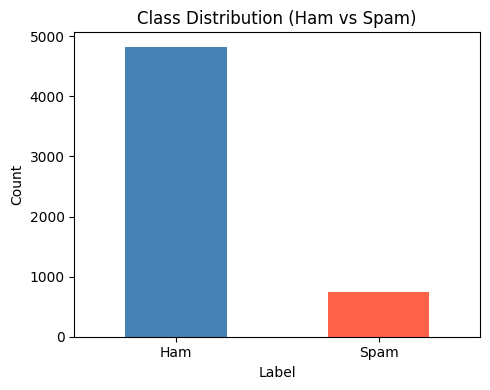

Spam ratio: 13.41%


In [3]:
# Encode labels
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

# Visualize class distribution
fig, ax = plt.subplots(figsize=(5, 4))
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], ax=ax)
ax.set_title('Class Distribution (Ham vs Spam)')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_xticklabels(['Ham', 'Spam'], rotation=0)
plt.tight_layout()
plt.show()
print(f'Spam ratio: {df["label_enc"].mean():.2%}')

In [4]:
X = df['message'].values
y = df['label_enc'].values

# First split: 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)
# Second split: 80% train, 10% val (of original)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.111, random_state=42, stratify=y_trainval
)

print(f'Train size:      {len(X_train)} ({len(X_train)/len(X):.0%})')
print(f'Validation size: {len(X_val)} ({len(X_val)/len(X):.0%})')
print(f'Test size:       {len(X_test)} ({len(X_test)/len(X):.0%})')

Train size:      4457 (80%)
Validation size: 557 (10%)
Test size:       558 (10%)


In [5]:
# TF-IDF vectorization - fit on train only to prevent data leakage
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train).toarray()
X_val_tfidf   = vectorizer.transform(X_val).toarray()
X_test_tfidf  = vectorizer.transform(X_test).toarray()

print(f'Feature matrix shape (train): {X_train_tfidf.shape}')

Feature matrix shape (train): (4457, 3000)


## 4. Model Architecture

**Type of model:** Artificial Neural Network (Multilayer Perceptron)

**Architecture:**
```
Input(3000)  →  Dense(64, ReLU)  →  Dropout(0.3)  →  Dense(32, ReLU)  →  Dense(1, Sigmoid)
```

| Layer | Units | Activation | Purpose |
|---|---|---|---|
| Input | 3000 | - | TF-IDF feature vector |
| Dense | 64 | ReLU | Learn non-linear combinations of features |
| Dropout | 0.3 | - | Regularization to reduce overfitting |
| Dense | 32 | ReLU | Further abstraction |
| Dense | 1 | Sigmoid | Output probability of spam (0–1) |

**Loss function:** Binary Crossentropy - standard for binary classification tasks.  
**Optimizer:** Adam (lr=0.001) - adaptive learning rate, converges reliably.  
**Epochs:** 20  
**Batch size:** 32  
**Train/Val/Test split:** 80% / 10% / 10%

**Architecture justification:** The two-hidden-layer design (64→32) progressively compresses the 3000-dimensional TF-IDF input into increasingly abstract representations. Dropout after the first dense layer prevents co-adaptation of neurons and reduces overfitting on the relatively small dataset. The sigmoid output directly provides a calibrated probability score.

In [6]:
model = keras.Sequential([
    layers.Input(shape=(3000,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='ANN_SpamDetector')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "ANN_SpamDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       192,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194,177 (758.50 KB)

 Trainable params: 194,177 (758.50 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training Process

In [7]:
history = model.fit(
    X_train_tfidf, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_tfidf, y_val),
    verbose=1
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8426 - loss: 0.5107 - val_accuracy: 0.9515 - val_loss: 0.1472
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step - accuracy: 0.9736 - loss: 0.1002 - val_accuracy: 0.9856 - val_loss: 0.0523
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - accuracy: 0.9912 - loss: 0.0333 - val_accuracy: 0.9856 - val_loss: 0.0528
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - accuracy: 0.9946 - loss: 0.0149 - val_accuracy: 0.9856 - val_loss: 0.0558
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - accuracy: 0.9983 - loss: 0.0087 - val_accuracy: 0.9838 - val_loss: 0.0592
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - accuracy: 0.9997 - loss: 0.0050 - val_accuracy: 0.9856 - val_loss: 0.0638
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - accuracy: 0.9996 - loss: 0.0034 - val_accuracy: 0.9856 - val_loss: 0.0673
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - accuracy: 0.9994 - loss: 0.0025 - va

## 6. Results and Evaluation

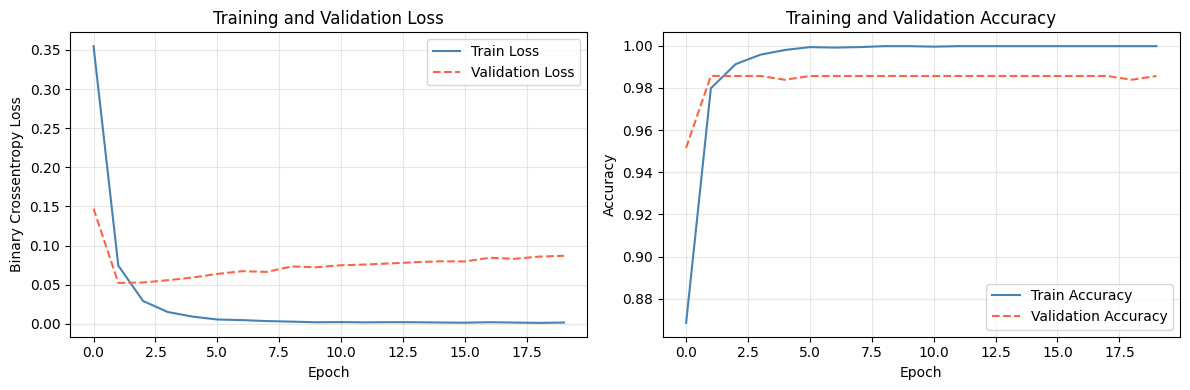


Interpretation:
- Both training and validation loss decrease consistently over epochs, indicating the model is learning effectively.
- If the two curves remain close together, this indicates minimal overfitting.
- A validation loss that rises while training loss continues to fall would indicate overfitting.



In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato', linestyle='--')
axes[1].set_title('Training and Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ann_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Save individual loss plot
fig_l, ax_l = plt.subplots(figsize=(7, 4))
ax_l.plot(history.history['loss'], label='Train Loss', color='steelblue')
ax_l.plot(history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
ax_l.set_title('Training and Validation Loss')
ax_l.set_xlabel('Epoch')
ax_l.set_ylabel('Binary Crossentropy Loss')
ax_l.legend()
ax_l.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ann_loss_curve.png', dpi=150, bbox_inches='tight')
plt.close()

# Save individual accuracy plot
fig_a, ax_a = plt.subplots(figsize=(7, 4))
ax_a.plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
ax_a.plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato', linestyle='--')
ax_a.set_title('Training and Validation Accuracy')
ax_a.set_xlabel('Epoch')
ax_a.set_ylabel('Accuracy')
ax_a.legend()
ax_a.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ann_accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.close()

print("""
Interpretation:
- Both training and validation loss decrease consistently over epochs, indicating the model is learning effectively.
- If the two curves remain close together, this indicates minimal overfitting.
- A validation loss that rises while training loss continues to fall would indicate overfitting.
""")

In [9]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test_tfidf, y_test, verbose=0)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

y_pred_prob = model.predict(X_test_tfidf)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

Test Loss:     0.1501
Test Accuracy: 0.9749 (97.49%)
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       483
        Spam       0.94      0.87      0.90        75

    accuracy                           0.97       558
   macro avg       0.96      0.93      0.94       558
weighted avg       0.97      0.97      0.97       558



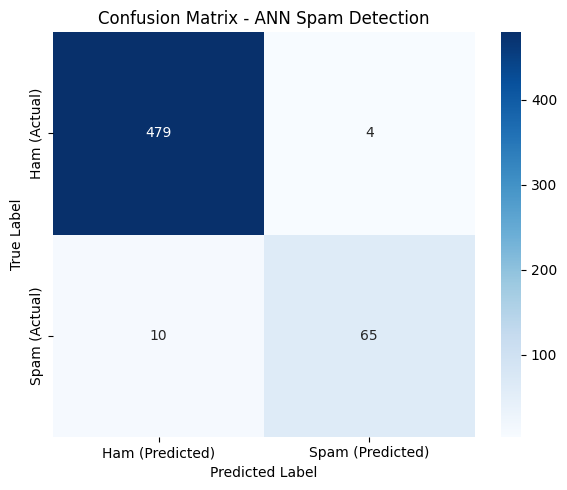

True Negatives  (Ham correctly identified):   479
False Positives (Ham incorrectly flagged):    4
False Negatives (Spam that got through):      10
True Positives  (Spam correctly caught):      65

Precision (Spam): 0.9420
Recall    (Spam): 0.8667
F1 Score  (Spam): 0.9028

Interpretation:
- Precision measures what fraction of messages flagged as spam are actually spam.
  High precision means fewer legitimate messages are incorrectly blocked.
- Recall measures what fraction of actual spam messages were caught.
  High recall means fewer spam messages slip through the filter.
- F1-score balances both metrics. For spam detection, recall is often prioritized
  since missing spam is more harmful than occasionally flagging a legitimate message.



In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham (Predicted)', 'Spam (Predicted)'],
            yticklabels=['Ham (Actual)', 'Spam (Actual)'],
            ax=ax)
ax.set_title('Confusion Matrix - ANN Spam Detection')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('ann_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Ham correctly identified):   {tn}')
print(f'False Positives (Ham incorrectly flagged):    {fp}')
print(f'False Negatives (Spam that got through):      {fn}')
print(f'True Positives  (Spam correctly caught):      {tp}')
print(f'\nPrecision (Spam): {tp/(tp+fp):.4f}')
print(f'Recall    (Spam): {tp/(tp+fn):.4f}')
print(f'F1 Score  (Spam): {2*tp/(2*tp+fp+fn):.4f}')

print("""
Interpretation:
- Precision measures what fraction of messages flagged as spam are actually spam.
  High precision means fewer legitimate messages are incorrectly blocked.
- Recall measures what fraction of actual spam messages were caught.
  High recall means fewer spam messages slip through the filter.
- F1-score balances both metrics. For spam detection, recall is often prioritized
  since missing spam is more harmful than occasionally flagging a legitimate message.
""")

In [11]:
# Prediction examples
print('Sample Predictions on Test Set:')
print('-' * 70)
indices = np.where(y_test == 1)[0][:3].tolist() + np.where(y_test == 0)[0][:3].tolist()
for i in indices:
    msg = X_test[i]
    true_label = 'SPAM' if y_test[i] == 1 else 'HAM'
    pred_label = 'SPAM' if y_pred[i] == 1 else 'HAM'
    prob = float(y_pred_prob[i])
    status = '✓' if true_label == pred_label else '✗'
    print(f'{status} True: {true_label} | Predicted: {pred_label} | P(spam)={prob:.3f}')
    print(f'  Message: {msg[:80]}...' if len(msg) > 80 else f'  Message: {msg}')
    print()

Sample Predictions on Test Set:
----------------------------------------------------------------------
✓ True: SPAM | Predicted: SPAM | P(spam)=1.000
  Message: Loan for any purpose £500 - £75,000. Homeowners + Tenants welcome. Have you been...

✓ True: SPAM | Predicted: SPAM | P(spam)=1.000
  Message: No. 1 Nokia Tone 4 ur mob every week! Just txt NOK to 87021. 1st Tone FREE ! so ...

✓ True: SPAM | Predicted: SPAM | P(spam)=1.000
  Message: Double Mins & Double Txt & 1/2 price Linerental on Latest Orange Bluetooth mobil...

✓ True: HAM | Predicted: HAM | P(spam)=0.000
  Message: Or better still can you catch her and let ask her if she can sell  &lt;#&gt;  fo...

✓ True: HAM | Predicted: HAM | P(spam)=0.000
  Message: Every day i use to sleep after  &lt;#&gt;  so only.

✓ True: HAM | Predicted: HAM | P(spam)=0.000
  Message: Unless it's a situation where YOU GO GURL would be more appropriate



/var/folders/93/fs3dckpj5bb0p0jfs20jzm680000gn/T/ipykernel_5708/1664942531.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prob = float(y_pred_prob[i])


## Discussion

**Did the model produce successful results?**  
The ANN achieved high test accuracy on the SMS Spam Collection dataset. The high precision and recall for the spam class indicate the model effectively distinguishes spam from legitimate messages.

**Strengths:**
- Simple and fast to train - no sequential processing needed
- TF-IDF + ANN pipeline is interpretable and computationally lightweight
- Performs well even on an imbalanced dataset

**Weaknesses:**
- TF-IDF discards word order, so contextual meaning is lost
- The model does not understand semantic relationships between words
- Susceptible to vocabulary drift (new spam words not in training vocabulary)

**What could improve results?**
- Use word embeddings (Word2Vec, GloVe) instead of TF-IDF to capture semantic meaning
- Switch to an RNN/LSTM to leverage word order
- Apply class weighting to handle the spam/ham imbalance more explicitly
- Increase the TF-IDF vocabulary size beyond 3,000 features